<a href="https://colab.research.google.com/github/DienAkbar25/DesainAnalisisAlgoritma/blob/Lolo/DAA(TRIP_PLANNER).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [105]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque
import time
from itertools import combinations

In [89]:
places = {
    1: "Malioboro",
    2: "Tugu Jogja",
    3: "Alun-Alun Kidul",
    4: "Keraton Yogyakarta",
    5: "Taman Sari",
    6: "Museum Sonobudoyo",
    7: "Candi Prambanan",
    8: "Ratu Boko",
    9: "Tebing Breksi",
    10: "Kaliurang",
    11: "Basecamp Lava Tour Merapi",
    12: "Museum Ullen Sentalu",
    13: "Pantai Parang Teritis",
    14: "HeHa Sky View",
    15: "Hutam Pinus Pengger"
}

In [90]:
day = {
    1: 1, 2: 1, 3: 1,
    4: 2, 5: 2, 6: 2,
    7: 3, 8: 3, 9: 3,
    10: 4, 11: 4, 12: 4,
    13: 5, 14: 5, 15: 5
}

N = len(places)

In [101]:
order_by_day = {}
for d in sorted(set(day.values())):
    order_by_day[d] = sorted([n for n,t in day.items() if t == d])

linear_graph = {n: [] for n in places.keys()}
days_sorted = sorted(order_by_day.keys())

for i, d in enumerate(days_sorted):
    seq = order_by_day[d]

    # chain dalam 1 hari
    for j in range(len(seq) - 1):
        linear_graph[seq[j]].append((seq[j+1], 1))

    # connect ke hari berikutnya
    if i < len(days_sorted) - 1:
        last = seq[-1]
        next_first = order_by_day[days_sorted[i+1]][0]
        linear_graph[last].append((next_first, 1))

print("Linear adjacency list:\n")
for u in sorted(linear_graph.keys()):
    print(f"{u:2d} -> {linear_graph[u]}")

Linear adjacency list:

 1 -> [(2, 1)]
 2 -> [(3, 1)]
 3 -> [(4, 1)]
 4 -> [(5, 1)]
 5 -> [(6, 1)]
 6 -> [(7, 1)]
 7 -> [(8, 1)]
 8 -> [(9, 1)]
 9 -> [(10, 1)]
10 -> [(11, 1)]
11 -> [(12, 1)]
12 -> [(13, 1)]
13 -> [(14, 1)]
14 -> [(15, 1)]
15 -> []


In [102]:
def linear_pos(order_by_day, x_step=3.0, y_step=2.0):
    pos = {}
    maxlen = max(len(v) for v in order_by_day.values())

    for i, d in enumerate(sorted(order_by_day.keys())):
        seq = order_by_day[d]
        x = i * x_step
        mid = (maxlen - 1) / 2
        for j, node in enumerate(seq):
            y = (mid - j) * y_step
            pos[node] = (x, y)

    return pos

pos = linear_pos(order_by_day)

In [103]:
def topo_kahn(adj):
    indeg = {n: 0 for n in adj}
    for u, edges in adj.items():
        for v, w in edges:
            indeg[v] += 1

    dq = deque([n for n in indeg if indeg[n] == 0])
    res = []

    while dq:
        u = dq.popleft()
        res.append(u)
        for v, w in adj[u]:
            indeg[v] -= 1
            if indeg[v] == 0:
                dq.append(v)
    return res


def topo_dfs(adj):
    visited = {n: False for n in adj}
    stack = []

    def dfs(u):
        visited[u] = True
        for v, w in adj[u]:
            if not visited[v]:
                dfs(v)
        stack.append(u)

    for n in sorted(adj.keys()):
        if not visited[n]:
            dfs(n)

    stack.reverse()
    return stack


In [106]:
def kendall_stability(a, b):
    assert set(a) == set(b)
    pos_b = {v: i for i, v in enumerate(b)}

    n = len(a)
    discord = 0
    total = 0

    for i, j in combinations(range(n), 2):
        u = a[i]; v = a[j]
        if pos_b[u] > pos_b[v]:
            discord += 1
        total += 1

    return 1 - (discord / total)

stability = kendall_stability(order_kahn, order_dfs)


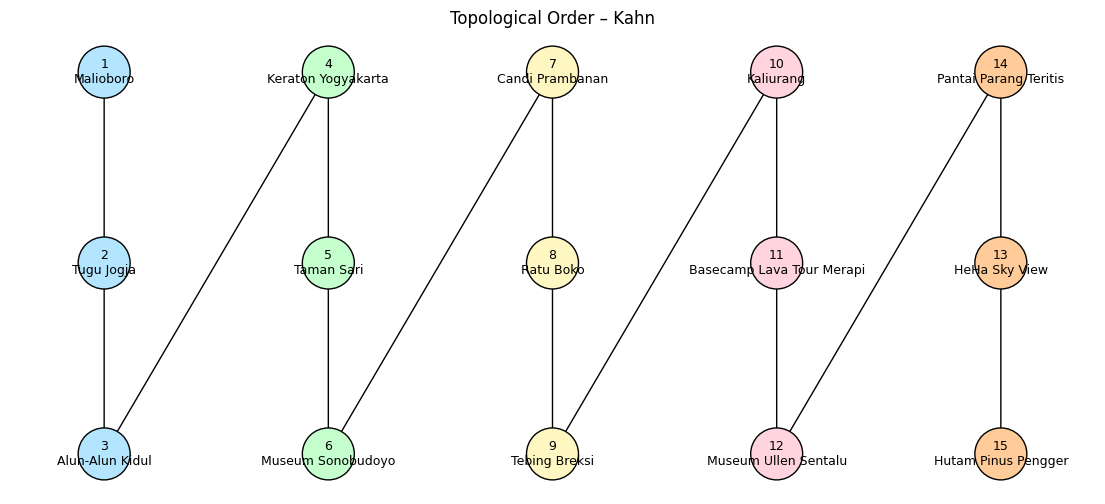

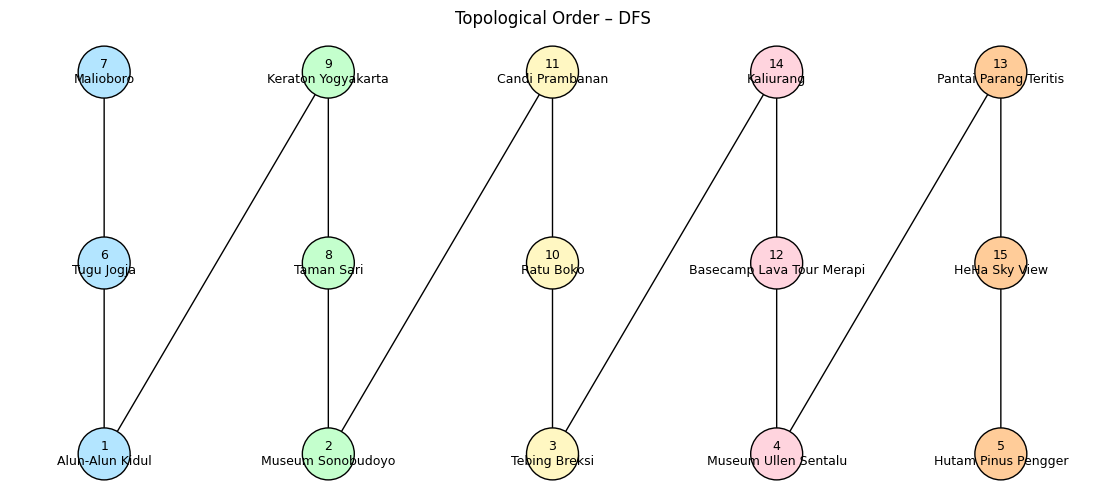

In [109]:
def draw_topo(order, title):
    G = nx.DiGraph()
    for u, edges in linear_graph.items():
        for v, w in edges:
            G.add_edge(u, v, weight=w)

    # rank topo
    rank = {node: i+1 for i, node in enumerate(order)}

    # warna per hari
    colors = {
        1:"#b3e5ff", 2:"#c4ffcd", 3:"#fff7c2",
        4:"#ffd4de", 5:"#ffcc99"
    }
    node_colors = [colors[day[n]] for n in G.nodes()]

    plt.figure(figsize=(14,6))
    nx.draw_networkx_nodes(G, pos, node_size=1400,
                           node_color=node_colors, edgecolors="black")
    nx.draw_networkx_edges(G, pos, arrowstyle="-|>", arrowsize=16)

    labels = {n: f"{rank[n]}\n{places[n]}" for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=9)

    plt.title(title)
    plt.axis("off")
    plt.show()

draw_topo(order_kahn, "Topological Order – Kahn")
draw_topo(order_dfs,  "Topological Order – DFS")

In [108]:
print("\n==================== HASIL ====================")
print("Kahn:", order_kahn)
print("DFS :", order_dfs)
print()
print(f"Runtime Kahn : {time_kahn:.6f} ms")
print(f"Runtime DFS  : {time_dfs:.6f} ms")
print(f"Stability    : {stability:.4f} (1 = identical)")
print("=================================================")


==================== HASIL ====================
Kahn: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 13, 15]
DFS : [3, 6, 9, 12, 15, 2, 1, 5, 4, 8, 7, 11, 13, 10, 14]

Runtime Kahn : 0.029230 ms
Runtime DFS  : 0.015430 ms
Stability    : 0.6571 (1 = identical)
